In [1]:
!pip freeze
!python --version

In [2]:
!nvidia-smi

In [5]:
import datetime
import os

import numpy as np
from torch.utils.data import Subset, DataLoader

from leaf_seg.dataset.plantdreamer_instance import build_dataset
from leaf_seg.instance.build import build_reporter
from leaf_seg.instance.train import fit, run
from leaf_seg.instance.finetune import finetune, load_pretrained_weights
from leaf_seg.common.config import InstanceTrainConfig, SemanticFinetuneConfig

In [6]:
def make_fixed_subset(dataset, fraction=None, n=None, seed=0):
    assert (fraction is None) ^ (n is None), "Specify exactly one of fraction or n"
    rng = np.random.default_rng(seed)

    N = len(dataset)
    k = int(round(N * fraction)) if fraction is not None else int(n)
    k = max(1, min(N, k))

    idx = rng.permutation(N)[:k].tolist()
    return Subset(dataset, idx)

In [7]:
from IPython.display import clear_output, display, Image as IPyImage
from pathlib import Path
import pandas as pd

def attach_notebook_viz(reporter, *, tail=10, show_csv=True, show_png=True):
    orig_log_epoch = reporter.log_epoch
    out_dir = Path(reporter.output_dir)
    csv_path = out_dir / "results.csv"
    png_path = out_dir / "results.png"

    def log_epoch_with_viz(epoch, epochs, train_stats, val_stats, lr):
        orig_log_epoch(epoch, epochs, train_stats, val_stats, lr)

        clear_output(wait=True)

        if show_csv and csv_path.exists():
            display(pd.read_csv(csv_path).tail(tail))

        if show_png and png_path.exists():
            # width is in pixels
            display(IPyImage(filename=str(png_path), width=840))

    reporter.log_epoch = log_epoch_with_viz
    return reporter


In [10]:
import logging

from leaf_seg.common.config import InstanceFinetuneConfig
from leaf_seg.dataset.plantdreamer_instance import coco_collate_fn
from leaf_seg.instance.build import setup_maskrcnn

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

DATASET = "bean_instance_real"
trn_ds, val_ds, spec = build_dataset(
    dataset_id=DATASET,
    registry_path="data/datasets.yaml",
)

for x in range(1, 11):
    cfg = InstanceFinetuneConfig(
        dataset=DATASET,
        num_classes=4,
        batch_size=8,
        num_workers=4,
        lr=0.00005,
        epochs=100,
        use_amp=True,
        progress=True,
        ckpt="checkpoints/instance/train/20260222015751-train-maskrcnn-bean_instance_synth-instance/model_best.pth",
        freeze_epochs=10,
    )


    trn_sb = make_fixed_subset(trn_ds, fraction=x/10.0, seed=42)
    trn_loader = DataLoader(trn_sb, batch_size=cfg.batch_size, num_workers=cfg.num_workers, pin_memory=True, shuffle=True, drop_last=True, collate_fn=coco_collate_fn)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, num_workers=cfg.num_workers, pin_memory=True, shuffle=False,drop_last=False, collate_fn=coco_collate_fn)

    logger.info("Subset=%s percen=%s", len(trn_sb), x/10.0)

    model = setup_maskrcnn(num_classes=cfg.num_classes, dataset=cfg.dataset, device=cfg.device)
    model.to(cfg.device)
    load_pretrained_weights(model, cfg.ckpt, device=cfg.device, strict_load=cfg.strict_load)

    timestamp = datetime.datetime.now().strftime("%Y%m%d%H%M%S")
    cfg.output = os.path.join(cfg.output, f"{cfg.epochs}_epochs", f"{timestamp}-finetune[subset-{len(trn_sb)}]-{model.name}")
    reporter = build_reporter(cfg=cfg)
    reporter = attach_notebook_viz(reporter, tail=5)
    finetune(
        model=model,
        train_loader=trn_loader,
        val_loader=val_loader,
        cfg=cfg,
        reporter=reporter,
    )

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
ROOT = Path("checkpoints/instance/finetune/[20260223-234427]_maskrcnn_finetunes")
MONITOR_COL = "val/segm_AP"          # primary metric
CONVERGENCE_RATIO = 0.95             # epoch to reach 95% of best monitor metric
PLATEAU_EPS = 0.002                  # plateau improvement threshold (AP)
PLATEAU_PATIENCE = 10                # plateau patience in epochs
STABILITY_WINDOW = 10                # last-K epochs window for stability stats
THRESHOLDS = [0.10, 0.20, 0.30]       # AP thresholds for time-to-threshold plots (adjust to your regime)

_subset_re = re.compile(r"\[subset-(?P<n>\d+)\]")

def extract_real_count(run_name: str) -> int:
    m = _subset_re.search(run_name)
    if not m:
        raise ValueError(f"Could not parse subset size from: {run_name}")
    return int(m.group("n"))

def _as_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        if c != "epoch":
            out[c] = pd.to_numeric(out[c], errors="coerce")
    out["epoch"] = pd.to_numeric(out["epoch"], errors="coerce")
    return out

def add_cum_time(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "time/epoch" in out.columns and out["time/epoch"].notna().any():
        out["cum_time_sec"] = out["time/epoch"].fillna(0).cumsum()
    else:
        tr = out["time/train"].fillna(0) if "time/train" in out.columns else 0
        va = out["time/val"].fillna(0) if "time/val" in out.columns else 0
        out["cum_time_sec"] = (tr + va).cumsum()
    out["cum_time_hr"] = out["cum_time_sec"] / 3600.0
    return out

def first_crossing(df: pd.DataFrame, col: str, thr: float) -> tuple[int | None, float | None]:
    """Return (epoch, cum_time_sec) of first crossing col >= thr."""
    s = df[col]
    hit = df.index[s >= thr]
    if len(hit) == 0:
        return None, None
    i = hit[0]
    return int(df.loc[i, "epoch"]), float(df.loc[i, "cum_time_sec"])

def plateau_epoch(df: pd.DataFrame, col: str, eps: float, patience: int) -> int | None:
    """Earliest epoch after which improvement < eps over next patience epochs."""
    vals = df[col].to_numpy(dtype=float)
    if np.all(np.isnan(vals)):
        return None
    N = len(vals)
    for i in range(N - patience):
        cur = np.nanmax(vals[: i + 1])
        fut = np.nanmax(vals[i + 1 : i + 1 + patience])
        if not np.isfinite(cur) or not np.isfinite(fut):
            continue
        if fut - cur < eps:
            return int(df.loc[i, "epoch"])
    return None


In [10]:
summary_rows = []
full_rows = []

for run_dir in sorted([p for p in ROOT.iterdir() if p.is_dir()]):
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        continue

    df = pd.read_csv(csv_path)
    df = _as_numeric(df)
    df = add_cum_time(df)

    # Skip if monitor column missing or all NaN
    if MONITOR_COL not in df.columns or df[MONITOR_COL].notna().sum() == 0:
        continue

    real_count = extract_real_count(run_dir.name)

    # Best epoch by monitor
    best_idx = df[MONITOR_COL].idxmax()
    best_row = df.loc[best_idx]
    best_epoch = int(best_row["epoch"])
    best_time_sec = float(best_row["cum_time_sec"])
    best_value = float(best_row[MONITOR_COL])

    # Convergence epoch to 95% of best
    conv_thr = CONVERGENCE_RATIO * best_value
    conv_hits = df[df[MONITOR_COL] >= conv_thr]
    conv_epoch = int(conv_hits["epoch"].iloc[0]) if len(conv_hits) else None
    conv_time_sec = float(conv_hits["cum_time_sec"].iloc[0]) if len(conv_hits) else None

    # Precision/alignment gaps at best epoch
    segm_gap = None
    if "val/segm_AP50" in df.columns and "val/segm_AP75" in df.columns:
        if pd.notna(best_row["val/segm_AP50"]) and pd.notna(best_row["val/segm_AP75"]):
            segm_gap = float(best_row["val/segm_AP50"] - best_row["val/segm_AP75"])

    bbox_gap = None
    if "val/bbox_AP50" in df.columns and "val/bbox_AP75" in df.columns:
        if pd.notna(best_row["val/bbox_AP50"]) and pd.notna(best_row["val/bbox_AP75"]):
            bbox_gap = float(best_row["val/bbox_AP50"] - best_row["val/bbox_AP75"])

    # Stability over last K epochs (monitor)
    tail = df[MONITOR_COL].tail(STABILITY_WINDOW)
    stability_std = float(tail.std()) if tail.notna().sum() >= 2 else None
    stability_mad = float(tail.diff().abs().mean()) if tail.notna().sum() >= 2 else None

    # Plateau epoch (heuristic)
    plat_epoch = plateau_epoch(df, MONITOR_COL, eps=PLATEAU_EPS, patience=PLATEAU_PATIENCE)

    # Time-to-thresholds
    tt = {}
    for t in THRESHOLDS:
        e, ts = first_crossing(df, MONITOR_COL, t)
        tt[f"epoch_to_AP{int(t*100):02d}"] = e
        tt[f"time_to_AP{int(t*100):02d}_sec"] = ts

    # Total training time
    total_time_sec = float(df["time/epoch"].sum()) if "time/epoch" in df.columns else float(df["cum_time_sec"].iloc[-1])

    summary_rows.append({
        "run": run_dir.name,
        "real_count": real_count,
        "best_epoch": best_epoch,
        "best_time_sec": best_time_sec,
        "best_time_hr": best_time_sec / 3600.0,
        "best_segm_AP": float(best_row.get("val/segm_AP")) if "val/segm_AP" in df.columns else None,
        "best_segm_AP50": float(best_row.get("val/segm_AP50")) if "val/segm_AP50" in df.columns else None,
        "best_segm_AP75": float(best_row.get("val/segm_AP75")) if "val/segm_AP75" in df.columns else None,
        "best_segm_APs": float(best_row.get("val/segm_APs")) if "val/segm_APs" in df.columns else None,
        "best_segm_APm": float(best_row.get("val/segm_APm")) if "val/segm_APm" in df.columns else None,
        "best_segm_APl": float(best_row.get("val/segm_APl")) if "val/segm_APl" in df.columns else None,
        "best_bbox_AP": float(best_row.get("val/bbox_AP")) if "val/bbox_AP" in df.columns else None,
        "best_bbox_AP50": float(best_row.get("val/bbox_AP50")) if "val/bbox_AP50" in df.columns else None,
        "best_bbox_AP75": float(best_row.get("val/bbox_AP75")) if "val/bbox_AP75" in df.columns else None,
        "segm_AP50_AP75_gap": segm_gap,
        "bbox_AP50_AP75_gap": bbox_gap,
        "convergence_epoch_95pct": conv_epoch,
        "convergence_time_95pct_sec": conv_time_sec,
        "plateau_epoch": plat_epoch,
        "stability_last10_std": stability_std,
        "stability_last10_mad": stability_mad,
        "total_training_time_sec": total_time_sec,
        "total_training_time_hr": total_time_sec / 3600.0,
        **tt,
    })

    # keep full series for overlay plots
    tmp = df.copy()
    tmp["run"] = run_dir.name
    tmp["real_count"] = real_count
    full_rows.append(tmp)

summary = pd.DataFrame(summary_rows).sort_values("real_count").reset_index(drop=True)
full = pd.concat(full_rows, ignore_index=True).sort_values(["real_count", "epoch"]).reset_index(drop=True)

summary["delta_best_segm_AP"] = summary["best_segm_AP"].diff()


In [11]:
summary

,run,real_count,best_epoch,best_time_sec,best_time_hr,best_segm_AP,best_segm_AP50,best_segm_AP75,best_segm_APs,best_segm_APm,...,stability_last10_mad,total_training_time_sec,total_training_time_hr,epoch_to_AP10,time_to_AP10_sec,epoch_to_AP20,time_to_AP20_sec,epoch_to_AP30,time_to_AP30_sec,delta_best_segm_AP
0,finetune[subset-0]-maskrcnn-bean_instance_real,0,2,146.014603,0.040560,0.112408,0.196284,0.110479,0.032486,0.103715,...,0.000083,4480.507633,1.244585,2,146.014603,NaN,NaN,NaN,NaN,NaN
1,finetune[subset-10]-maskrcnn-bean_instance_real,10,73,3047.856820,0.846627,0.338986,0.509487,0.345029,0.066393,0.191149,...,0.000031,4087.166393,1.135324,1,56.062315,6.0,290.620215,14.0,663.398836,0.226578
2,finetune[subset-20]-maskrcnn-bean_instance_real,20,69,2741.936104,0.761649,0.360317,0.531010,0.376119,0.070852,0.250975,...,0.000259,3808.307172,1.057863,1,47.163863,3.0,138.330902,7.0,323.252024,0.021331
3,finetune[subset-30]-maskrcnn-bean_instance_real,30,39,1679.117100,0.466421,0.390409,0.564590,0.417606,0.106749,0.262543,...,0.000209,3862.836573,1.073010,1,46.598740,2.0,93.012602,5.0,233.751810,0.030092
4,finetune[subset-40]-maskrcnn-bean_instance_real,40,36,1602.630651,0.445175,0.402857,0.578964,0.438505,0.114269,0.267342,...,0.000110,3963.342793,1.100929,1,47.619076,2.0,99.029860,3.0,147.415541,0.012448
5,finetune[subset-50]-maskrcnn-bean_instance_real,50,31,1407.772819,0.391048,0.414635,0.592654,0.450230,0.115566,0.274209,...,0.000077,3887.413921,1.079837,1,47.539441,1.0,47.539441,3.0,147.385095,0.011778
6,finetune[subset-60]-maskrcnn-bean_instance_real,60,48,2066.167723,0.573935,0.422832,0.603668,0.467131,0.102132,0.278665,...,0.000081,3956.840916,1.099122,1,49.728054,1.0,49.728054,2.0,98.153992,0.008197
7,finetune[subset-70]-maskrcnn-bean_instance_real,70,30,1395.571575,0.387659,0.424348,0.613909,0.479513,0.115810,0.292477,...,0.000340,4076.758518,1.132433,1,50.935592,1.0,50.935592,2.0,100.354468,0.001516
8,finetune[subset-80]-maskrcnn-bean_instance_real,80,45,1995.531351,0.554314,0.426374,0.622175,0.471980,0.109162,0.294054,...,0.000250,4060.116716,1.127810,1,51.111651,1.0,51.111651,2.0,100.592595,0.002026
9,finetune[subset-90]-maskrcnn-bean_instance_real,90,25,1242.030131,0.345008,0.429748,0.615478,0.465893,0.120408,0.286230,...,0.000201,4375.340583,1.215372,1,55.177314,1.0,55.177314,2.0,110.821763,0.003374


In [12]:
%matplotlib inline

In [ ]:
# 1) Data efficiency: best segm AP vs real_count (log-x often useful)
x = summary["real_count"]
y = summary["best_segm_AP"]

plt.figure(figsize=(7,5))
plt.plot(x, y, marker="o")


for xi, yi in zip(x, y):
    plt.text(xi, yi, f'{yi:.3f}',
             ha='center',
             va='bottom')
    
plt.xlabel("Number of Real Training Images (subset size)")
plt.xticks(np.arange(0, 110, step=10))
plt.ylabel("Best Validation Segm AP")
plt.title("Data Efficiency: Best Segm AP vs Real Data Size")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()



In [ ]:
# 2) Marginal gains: delta best AP as you add more real data


plt.figure(figsize=(7,5))
bars = plt.bar(summary["real_count"][1:], summary["delta_best_segm_AP"][1:], width=7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.3f}', ha='center',va='bottom')
plt.xlabel("Number of Real Training Images (subset size)")
plt.xticks(np.arange(0, 110, step=10))
plt.ylabel("Marginal Gain in Best Segm AP")
plt.title(r"Marginal Benefit of Additional Real Data [$\Delta \text{SegmAP}_k = \text{SegmAP}_k - \text{SegmAP}_{k-1}$]")
plt.tight_layout()
plt.show()

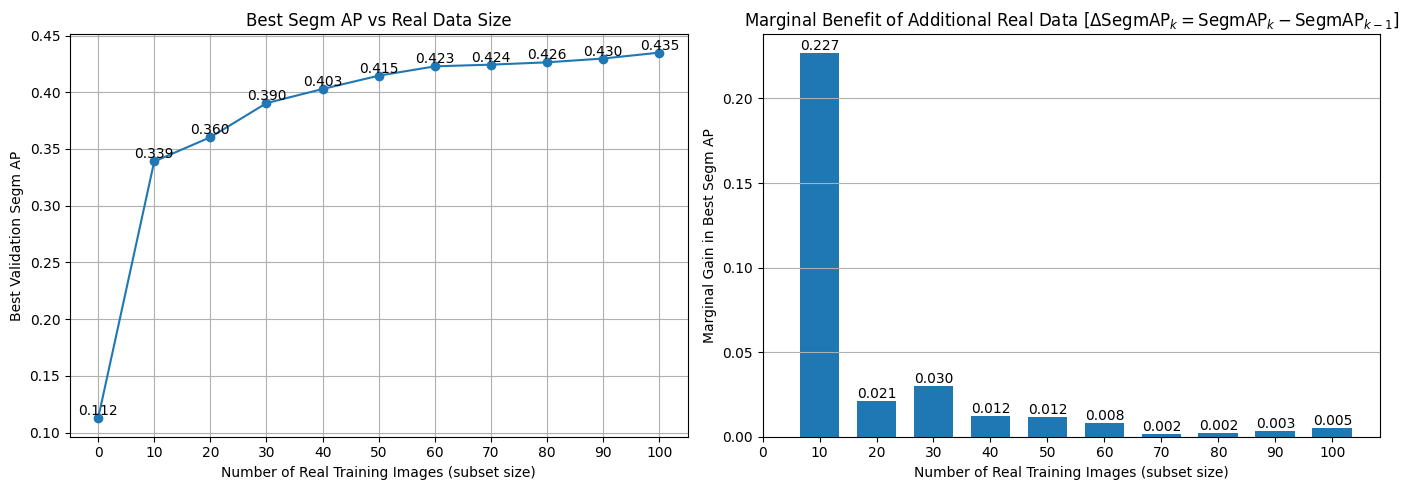

In [15]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Best Segm AP vs Real Data Size ---
x = summary["real_count"]
y = summary["best_segm_AP"]

ax1.plot(x, y, marker="o")
for xi, yi in zip(x, y):
    ax1.text(xi, yi, f"{yi:.3f}", ha="center", va="bottom")

ax1.set_xlabel("Number of Real Training Images (subset size)")
ax1.set_ylabel("Best Validation Segm AP")
ax1.set_title("Best Segm AP vs Real Data Size")
ax1.set_xticks(np.arange(0, 110, step=10))
ax1.grid(True, which="both")

# --- Right plot: Marginal Gain in Best Segm AP ---
bars = ax2.bar(summary["real_count"][1:], summary["delta_best_segm_AP"][1:], width=7)

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

ax2.set_xlabel("Number of Real Training Images (subset size)")
ax2.set_ylabel("Marginal Gain in Best Segm AP")
ax2.set_title(
    r"Marginal Benefit of Additional Real Data "
    r"[$\Delta \mathrm{SegmAP}_k = \mathrm{SegmAP}_k - \mathrm{SegmAP}_{k-1}$]"
)
ax2.set_xticks(np.arange(0, 110, step=10))
ax2.grid(True, axis="y", which="both")

plt.tight_layout()
plt.show()

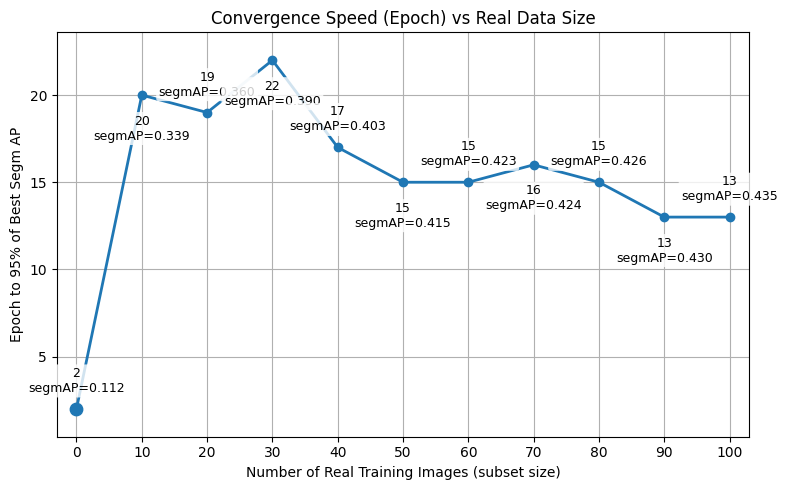

In [28]:
# 3) Convergence speed: epoch to reach 95% of best AP
# x = summary["real_count"]
# y = summary["convergence_epoch_95pct"]

# plt.figure(figsize=(7,5))
# plt.plot(x, y, marker="o")

# for xi, yi in zip(x, y):
#     plt.text(xi, yi, f'{yi}',
#              ha='center',
#              va='bottom')

# plt.xlabel("Number of Real Training Images (subset size)")
# plt.xticks(np.arange(0, 110, step=10))
# plt.ylabel("Epoch to 95% of Best Segm AP")
# plt.title("Convergence Speed (Epoch) vs Real Data Size")
# plt.grid(True, which="both")
# plt.tight_layout()
# plt.show()


x = summary["real_count"].to_numpy()
y = summary["convergence_epoch_95pct"].astype(np.uint).to_numpy()
segmAP = summary["best_segm_AP"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))

# Main line
ax.plot(x, y, marker="o", linewidth=2, markersize=6)

# Optional: highlight the baseline (x=0) point
if len(x) > 0:
    ax.scatter([x[0]], [y[0]], s=80, zorder=3)

# Annotate points with alternating offsets to reduce overlap
for i, (xi, yi, m) in enumerate(zip(x, y, segmAP)):
    # Alternate annotation positions (up/down) for readability
    dy = 10 if i % 2 == 0 else -14
    va = "bottom" if dy > 0 else "top"
    
    ax.annotate(
        f"{int(yi)}\nsegmAP={m:.3f}",
        (xi, yi),
        xytext=(0, dy),
        textcoords="offset points",
        ha="center",
        va=va,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
    )

# Axes formatting
plt.xlabel("Number of Real Training Images (subset size)")
plt.xticks(np.arange(0, 110, step=10))
plt.ylabel("Epoch to 95% of Best Segm AP")
plt.title("Convergence Speed (Epoch) vs Real Data Size")
ax.set_xticks(np.arange(0, max(x) + 10, 10))
ax.grid(True) #  linestyle="--", alpha=0.35

# Add a little padding around data limits
ax.margins(x=0.03, y=0.08)

plt.tight_layout()
plt.show()

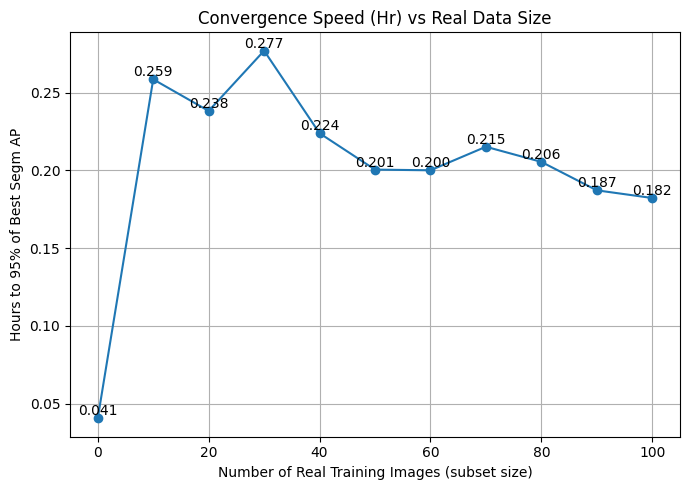

In [ ]:
# 4) Convergence speed in wall-clock time (if you care about compute efficiency)
plt.figure(figsize=(7,5))
x = summary["real_count"]
y = summary["convergence_time_95pct_sec"]/3600.0
plt.plot(x, y, marker="o")
for xi, yi in zip(x, y):
    plt.text(xi, yi, f'{yi:.3f}',
             ha='center',
             va='bottom')
plt.xlabel("Number of Real Training Images (subset size)")
plt.ylabel("Hours to 95% of Best Segm AP")
plt.title("Convergence Speed (Hr) vs Real Data Size") # Compute-Normalised Convergence
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

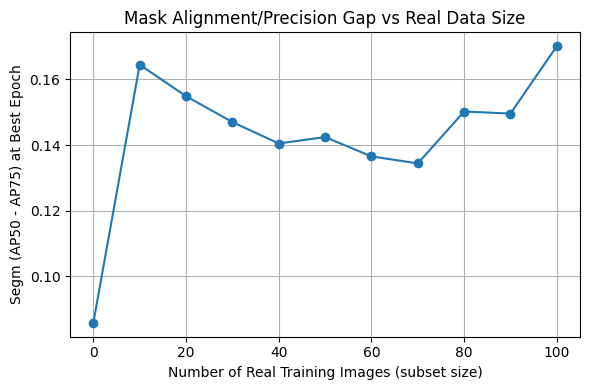

In [26]:
# 5) Precision/alignment gap: AP50 - AP75 (segm) vs real_count
plt.figure(figsize=(6,4))
plt.plot(summary["real_count"], summary["segm_AP50_AP75_gap"], marker="o")
plt.xlabel("Number of Real Training Images (subset size)")
plt.ylabel("Segm (AP50 - AP75) at Best Epoch")
plt.title("Mask Alignment/Precision Gap vs Real Data Size")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

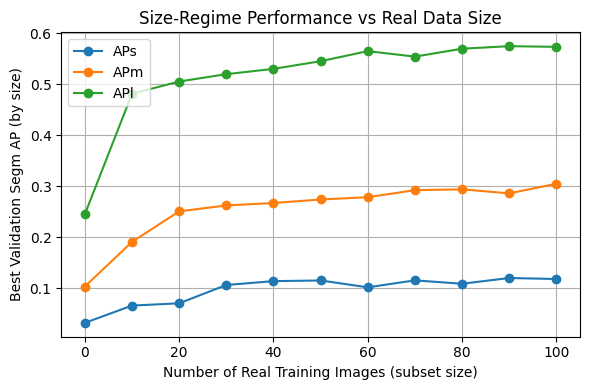

In [19]:
# 6) Size regime scaling: APs/APm/APl vs real_count (at best epoch)
plt.figure(figsize=(6,4))
plt.plot(summary["real_count"], summary["best_segm_APs"], marker="o", label="APs")
plt.plot(summary["real_count"], summary["best_segm_APm"], marker="o", label="APm")
plt.plot(summary["real_count"], summary["best_segm_APl"], marker="o", label="APl")
plt.xlabel("Number of Real Training Images (subset size)")
plt.ylabel("Best Validation Segm AP (by size)")
plt.title("Size-Regime Performance vs Real Data Size")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

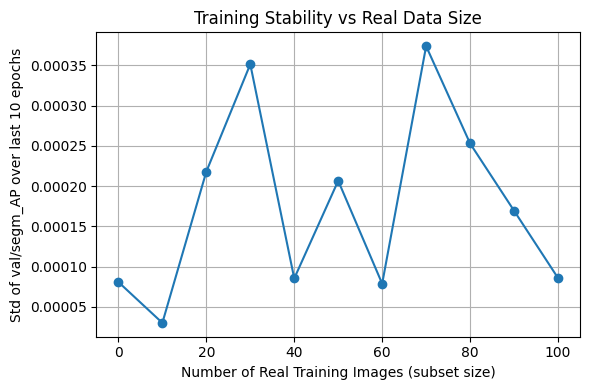

In [20]:
# 7) Stability/noise proxy: std of last K epochs vs real_count
plt.figure(figsize=(6,4))
plt.plot(summary["real_count"], summary["stability_last10_std"], marker="o")
plt.xlabel("Number of Real Training Images (subset size)")
plt.ylabel(f"Std of {MONITOR_COL} over last {STABILITY_WINDOW} epochs")
plt.title("Training Stability vs Real Data Size")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

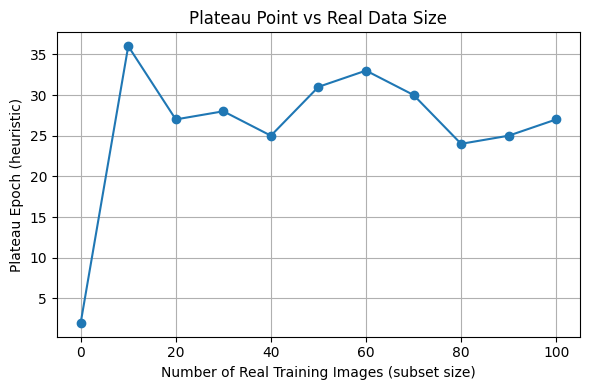

In [21]:
# 8) Plateau epoch (heuristic): when improvements effectively stop
plt.figure(figsize=(6,4))
plt.plot(summary["real_count"], summary["plateau_epoch"], marker="o")
plt.xlabel("Number of Real Training Images (subset size)")
plt.ylabel("Plateau Epoch (heuristic)")
plt.title("Plateau Point vs Real Data Size")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


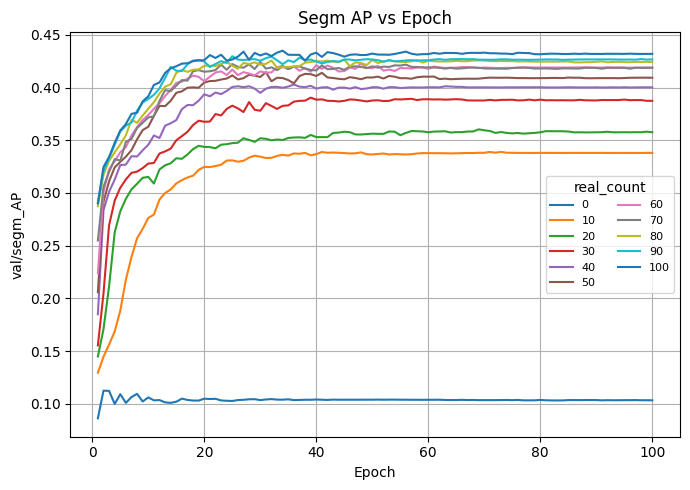

In [29]:
# 9) Overlay: segm AP vs epoch for all runs (convergence curves)
plt.figure(figsize=(7,5))
for rc, g in full.groupby("real_count"):
    plt.plot(g["epoch"], g[MONITOR_COL], label=str(rc))
plt.xlabel("Epoch")
plt.ylabel(MONITOR_COL)
plt.title("Segm AP vs Epoch")
plt.grid(True)
plt.legend(title="real_count", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


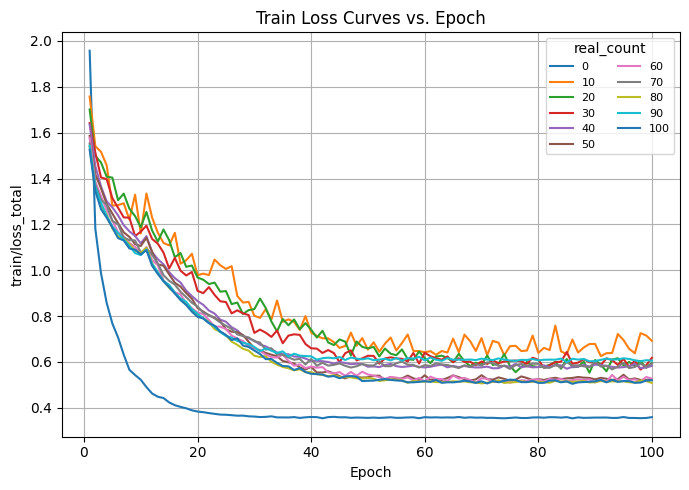

In [24]:
# 12) opt: training loss vs AP at best epoch (diagnostic, not a generalisation gap)
# (no val loss though we can still see if loss keeps dropping while AP saturates.)
if "train/loss_total" in full.columns:
    plt.figure(figsize=(7,5))
    for rc, g in full.groupby("real_count"):
        plt.plot(g["epoch"], g["train/loss_total"], label=str(rc))
    plt.xlabel("Epoch")
    plt.ylabel("train/loss_total")
    plt.title("Train Loss Curves vs. Epoch") # (context for AP behaviour)
    plt.grid(True)
    plt.legend(title="real_count", ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

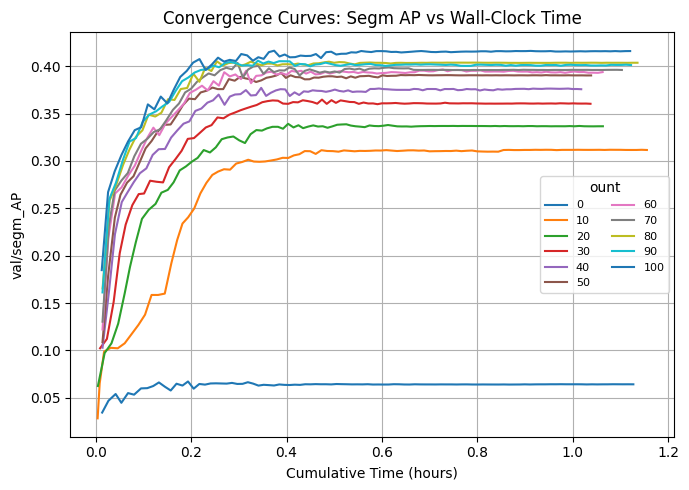

In [68]:
# 10) Overlay: segm AP vs cumulative wall-clock time (compute-normalised)
plt.figure(figsize=(7,5))
for rc, g in full.groupby("real_count"):
    plt.plot(g["cum_time_hr"], g[MONITOR_COL], label=str(rc))
plt.xlabel("Cumulative Time (hours)")
plt.ylabel(MONITOR_COL)
plt.title("Convergence Curves: Segm AP vs Wall-Clock Time")
plt.grid(True)
plt.legend(title="ount", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

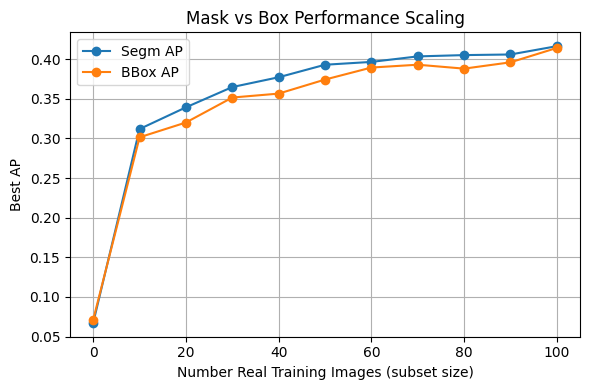

In [70]:
# 11) opt: compare masks vs boxes scaling directly (best epoch summaries)
plt.figure(figsize=(6,4))
plt.plot(summary["real_count"], summary["best_segm_AP"], marker="o", label="Segm AP")
plt.plot(summary["real_count"], summary["best_bbox_AP"], marker="o", label="BBox AP")
plt.xlabel("Number Real Training Images (subset size)")
plt.ylabel("Best AP")
plt.title("Mask vs Box Performance Scaling")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()